## Unsupervised Learning on Country Data

#### Objective: Categorise countries using socio-economic and health factors to identify nations in the direst need of aid, helping HELP International allocate $10 million strategically.

#### Goals
* Load and inspect the data
* Clean and preprocess features
* Apply scaling
* Find the best number of clusters with K-Means
* Try DBSCAN as a second clustering method
* Visualize clusters with PCA
* Create simple country-level insights

### 1. Install Required Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

### 2. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully.')

All libraries imported successfully.


### 3. Upload & Load Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Country-data.csv')

print('Dataset shape:', df.shape)
df.head()

Saving Country-data.csv to Country-data.csv
Dataset shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### 4. Quick inspection

In [4]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


In [5]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


### 5. Data Cleaning
Now, we will clean the data....
* Strip whitespace from column names
* Handling Duplicates
* Handling Missing values
* Check data type
* Understand the dataset

In [6]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

In [7]:
### Check the categories
df['country'].value_counts()

,count
country,
Afghanistan,1
Albania,1
Algeria,1
Angola,1
Antigua and Barbuda,1
...,...
Vanuatu,1
Venezuela,1
Vietnam,1


In [8]:
# Drop duplicate records
df = df.drop_duplicates()

In [9]:
# Force numeric types on feature columns
feature_cols = [c for c in df.columns if c != 'country']
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [10]:
## Check Misssing Values
missing = df[feature_cols].isna().sum()

In [11]:
# Impute missing values with column median
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

print(missing)

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [12]:
print('\nData types after cleaning:')
print(df.dtypes)
print('\nBasic statistics:')
df[feature_cols].describe().round(2)


Data types after cleaning:
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Basic statistics:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


### 6. Exploratory Data Analysis (EDA)

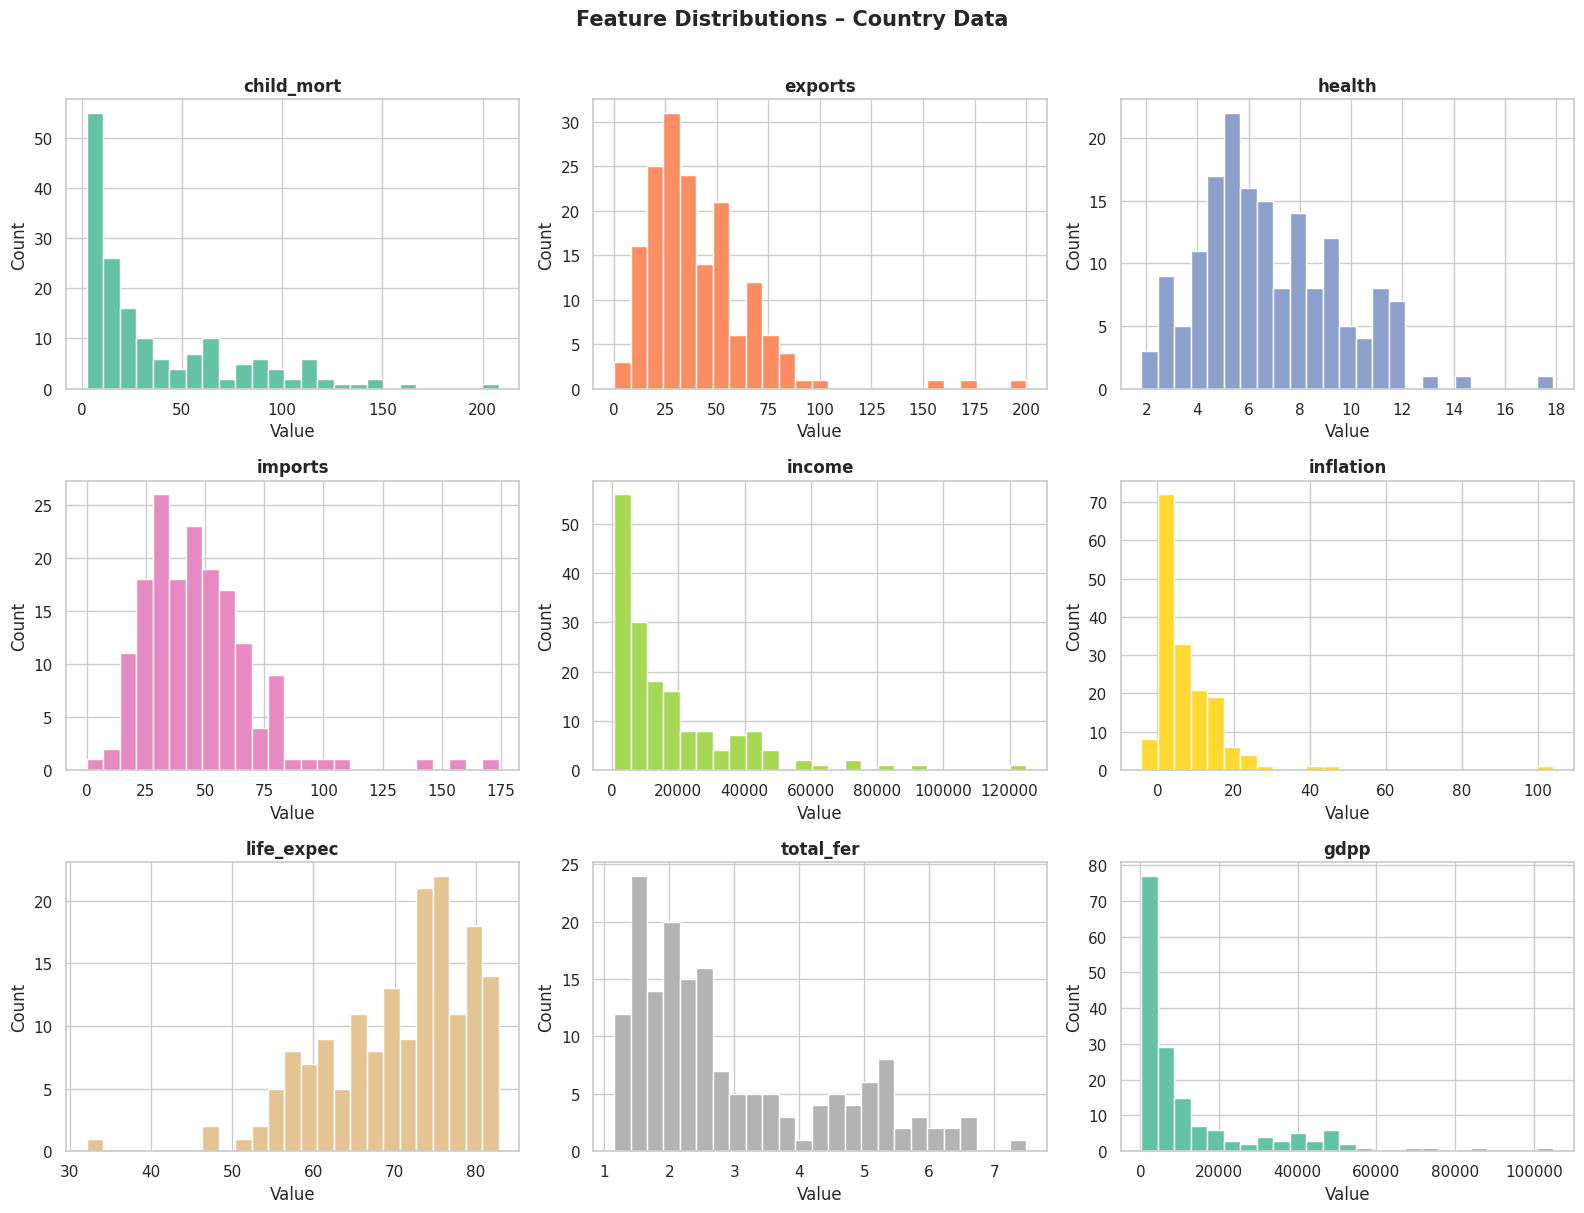

In [13]:
# let us see the distribution plots for each feature
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=25, color=sns.color_palette('Set2')[i % 8], edgecolor='white')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions – Country Data', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

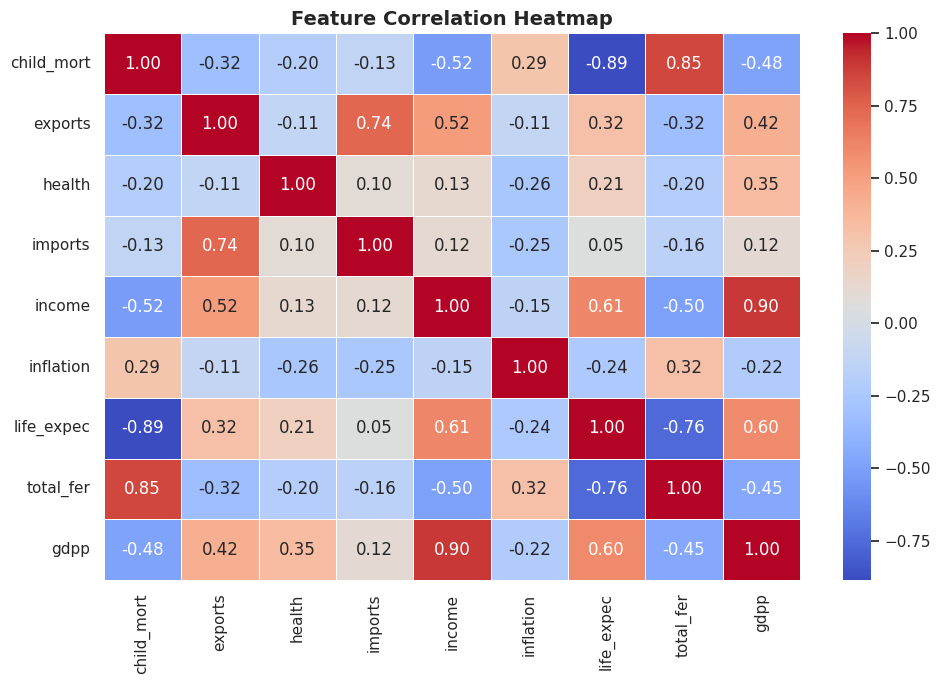

In [14]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

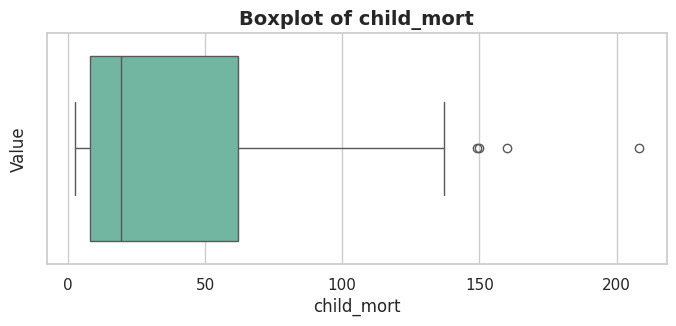

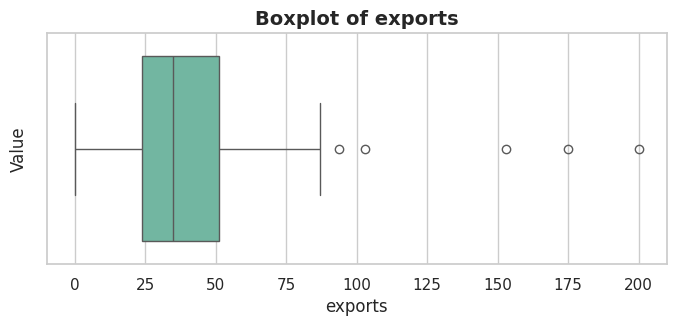

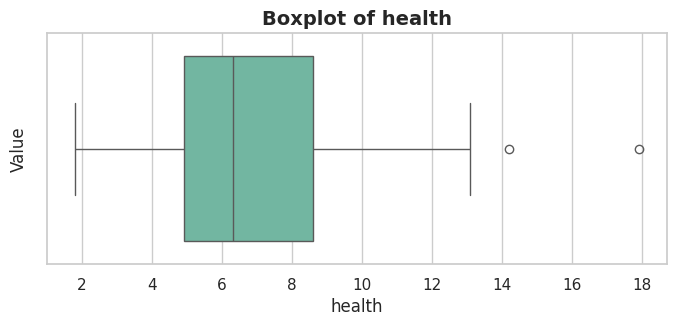

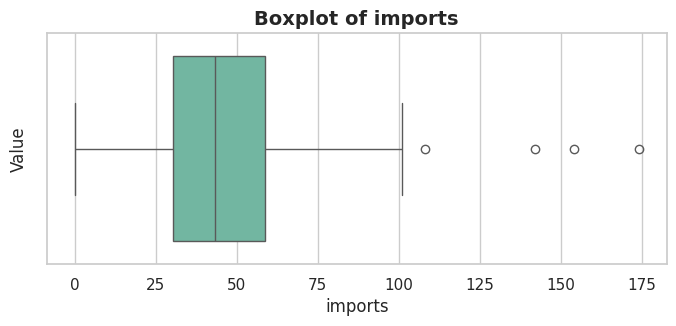

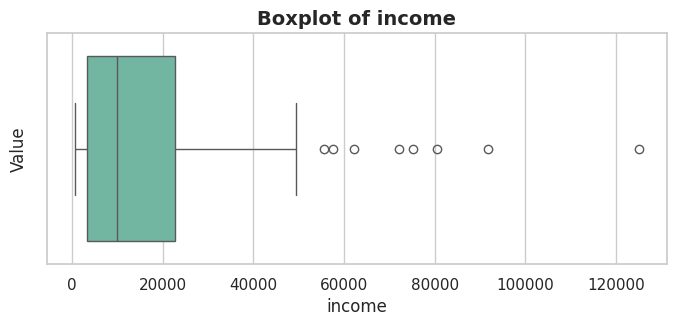

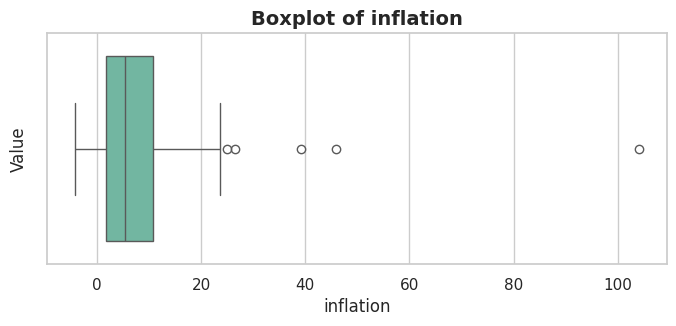

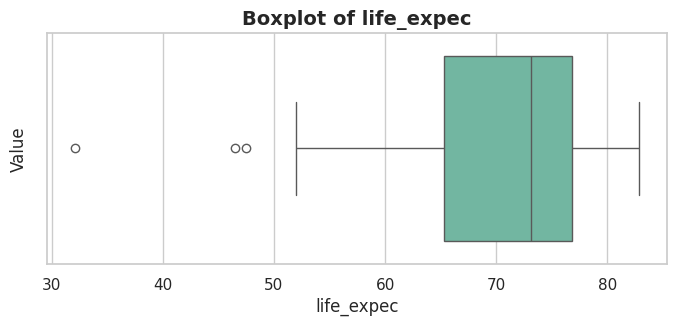

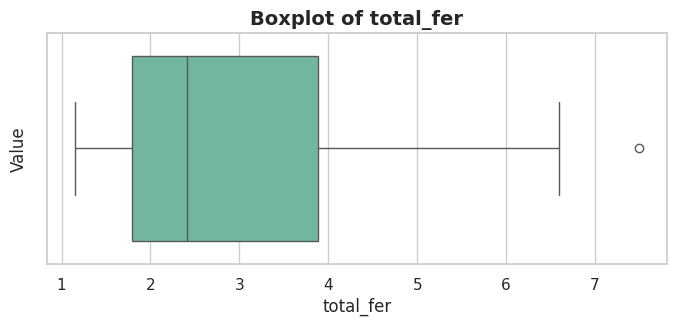

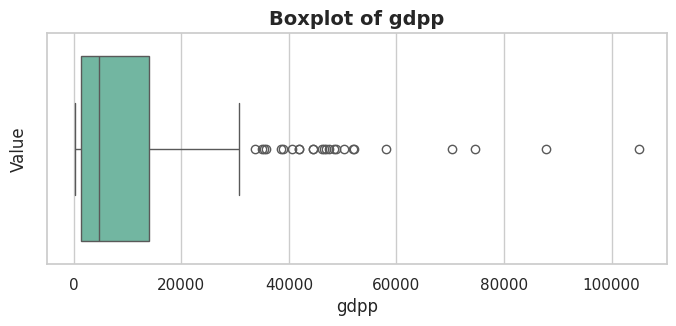

In [15]:
for col in feature_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x = df[col])
    plt.ylabel('Value')
    plt.title(f'Boxplot of {col}', fontsize=14, fontweight='bold')
    plt.show()

### 7. Feature Preparation & Scaling

In [16]:
country_names = df['country'].values
X = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)
print('Mean after scaling (~0):', X_scaled.mean(axis=0).round(4))
print('Std after scaling  (~1):', X_scaled.std(axis=0).round(4))

Feature matrix shape: (167, 9)
Mean after scaling (~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std after scaling  (~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 8. Elbow Method
 >cluster ranges k ∈ [2, 10] and then save inertia values

In [17]:
k_range = range(2, 11)
inertia_val = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_val.append(km.inertia_)

inertia_val

[1050.2145582853307,
 831.424435208687,
 700.52053697222,
 620.163371288842,
 558.4696598590399,
 495.8079455215346,
 457.5861478912421,
 427.80367198134667,
 403.2296125136434]

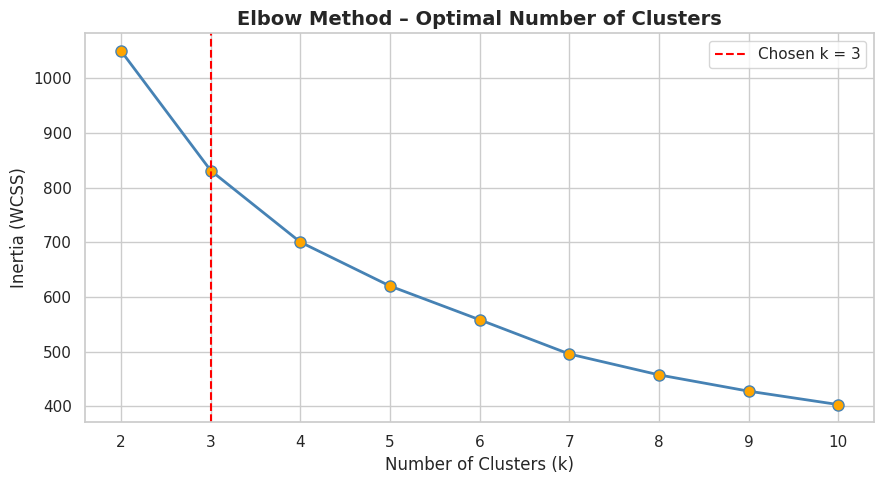

Inertia values: {2: 1050.2, 3: 831.4, 4: 700.5, 5: 620.2, 6: 558.5, 7: 495.8, 8: 457.6, 9: 427.8, 10: 403.2}


In [18]:
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertia_val, marker='o', linewidth=2, color='steelblue', markersize=8, markerfacecolor='orange')
plt.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Chosen k = 3')
plt.title('Elbow Method – Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.xticks(list(k_range))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('Inertia values:', dict(zip(k_range, [round(i,1) for i in inertia_val])))

### 9. K-Means Clustering
> So chosen best k = 3 and now we train K-Means model

In [19]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['kmeans_cluster'] = kmeans_labels

print('K-Means cluster counts:')
print(df['kmeans_cluster'].value_counts().sort_index())

K-Means cluster counts:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


### 10. Silhouette Score Evaluation (evaluating clustering performance)

In [20]:
silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f'K-Means Silhouette Score : {silhouette:.4f}')
print()
if silhouette > 0.5:
    print('Interpretation: Strong cluster structure (score > 0.5).')
elif silhouette > 0.25:
    print('Interpretation: Reasonable cluster structure (score 0.25–0.5).')
else:
    print('Interpretation: Weak cluster structure')

K-Means Silhouette Score : 0.2833

Interpretation: Reasonable cluster structure (score 0.25–0.5).


In [21]:
df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


### 11. DBSCAN Clustering
> now we try secondary comparative clustering model using DBSCAN

In [22]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['dbscan_cluster'] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'DBSCAN – Number of clusters found : {n_clusters_db}')
print(f'DBSCAN – Noise points (label = -1): {n_noise}')
print('\nDBSCAN cluster distribution:')
print(pd.Series(dbscan_labels).value_counts().sort_index())


DBSCAN – Number of clusters found : 1
DBSCAN – Noise points (label = -1): 30

DBSCAN cluster distribution:
-1     30
 0    137
Name: count, dtype: int64


### 12. K-Means vs DBSCAN.....comparison

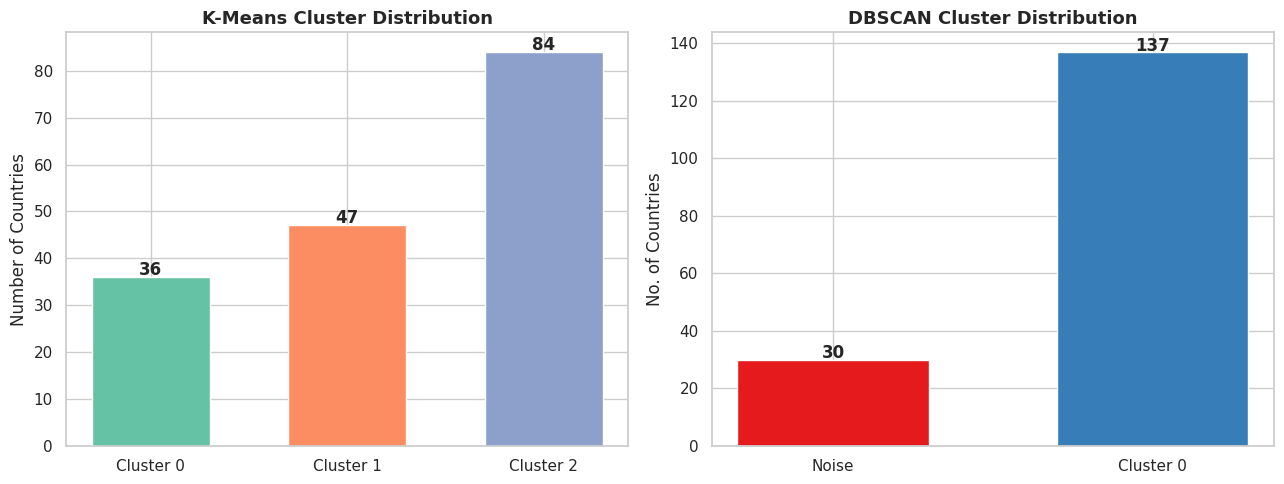

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# K-Means
km_counts = df['kmeans_cluster'].value_counts().sort_index()

axes[0].bar([f'Cluster {i}' for i in km_counts.index], km_counts.values,
            color=sns.color_palette('Set2', len(km_counts)), edgecolor='white', width=0.6)
axes[0].set_title('K-Means Cluster Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Countries')

for i, v in enumerate(km_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# DBSCAN
db_counts = df['dbscan_cluster'].value_counts().sort_index()

db_labelling_str = ['Noise' if l == -1 else f'Cluster {l}' for l in db_counts.index]

axes[1].bar(db_labelling_str, db_counts.values, color=sns.color_palette('Set1', len(db_counts)), edgecolor='white', width=0.6)
axes[1].set_title('DBSCAN Cluster Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('No. of Countries')

for i, v in enumerate(db_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 13. PCA & K-Means Scatterplot

In [24]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

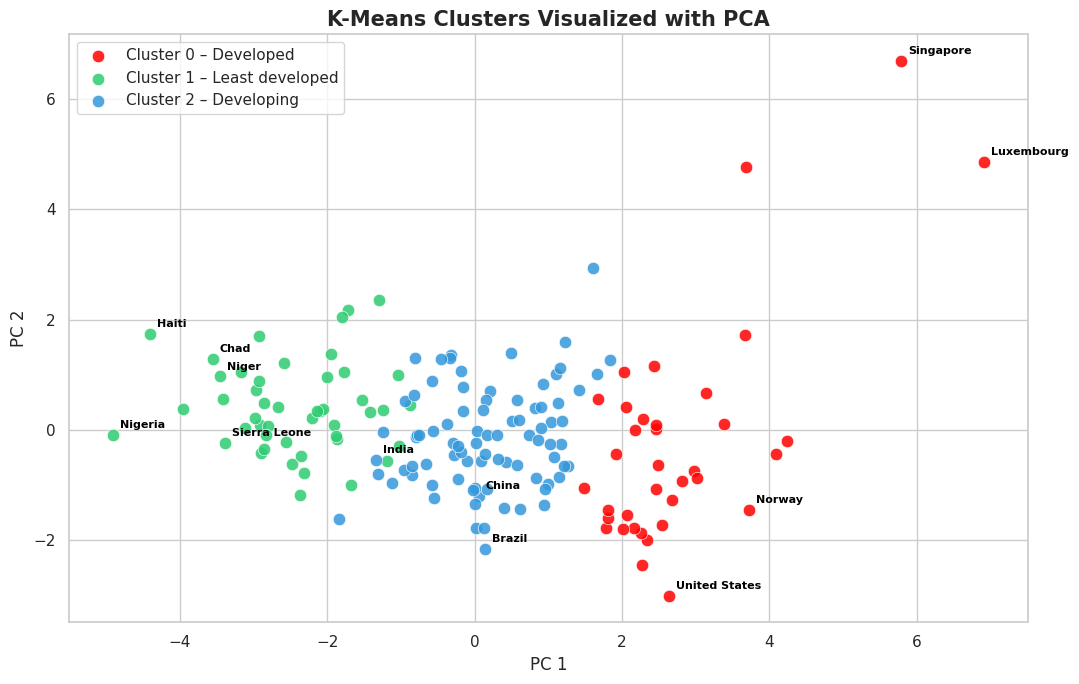

In [25]:
cluster_names  = {0: 'Cluster 0 – Developed', 1: 'Cluster 1 – Least developed', 2: 'Cluster 2 – Developing'}
cluster_colors = {0: 'red', 1: '#2ECC71', 2: '#3498DB'}
plt.figure(figsize=(11, 7))

for cluster_id in sorted(df['kmeans_cluster'].unique()):
    mask = kmeans_labels == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=cluster_colors[cluster_id], label=cluster_names[cluster_id],
                s=80, alpha=0.85, edgecolors='white', linewidth=0.5)

# to annotate a few countries on plot
notable = ['Haiti', 'Niger', 'Sierra Leone', 'Chad', 'Nigeria',
           'United States', 'Norway', 'Luxembourg', 'Singapore',
           'India', 'China', 'Brazil']
for i, name in enumerate(country_names):
    if name in notable:
        plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), textcoords='offset points', xytext=(5, 5),
                     fontsize=8, fontweight='bold', color='black')

plt.title('K-Means Clusters Visualized with PCA', fontsize=15, fontweight='bold')
plt.xlabel(f'PC 1', fontsize=12)
plt.ylabel(f'PC 2', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 14. Cluster profiling

In [26]:
cluster_profile = df.groupby('kmeans_cluster')[feature_cols].mean().round(2)
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


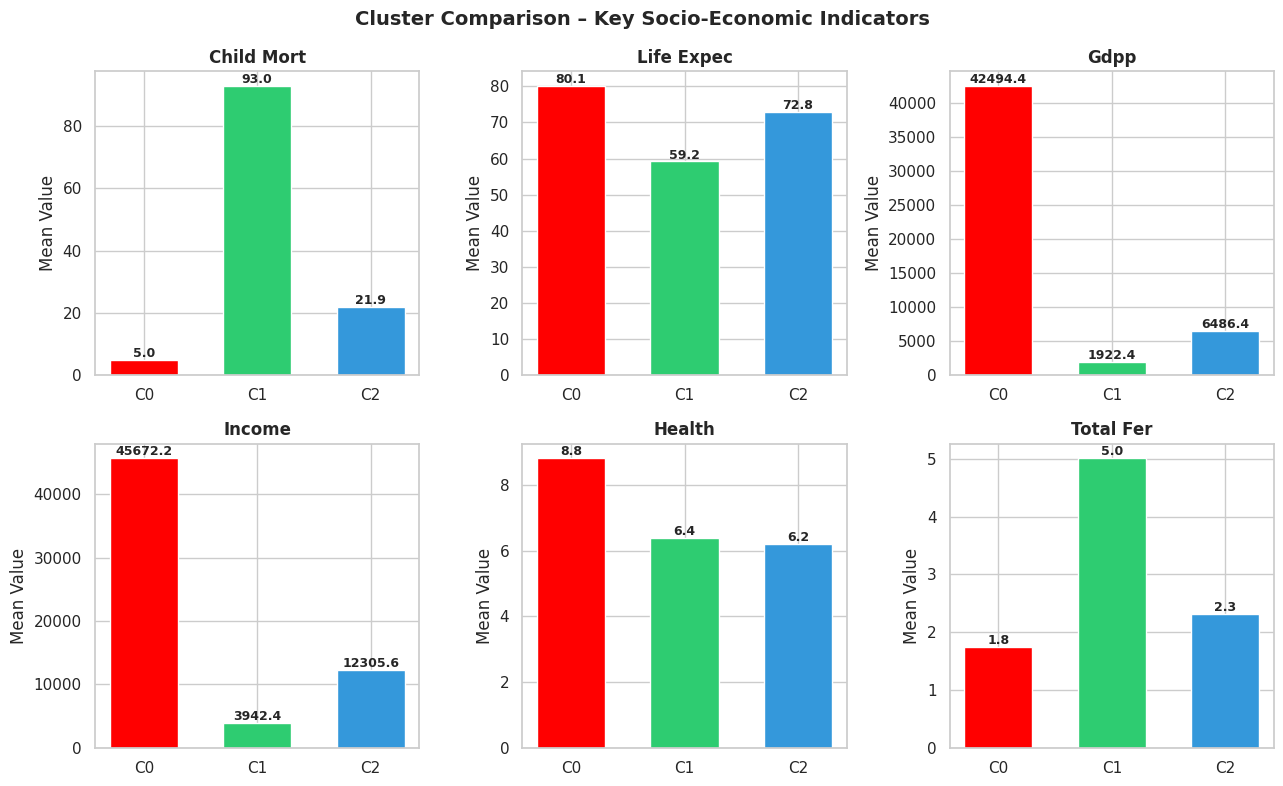

In [27]:
key_features = ['child_mort', 'life_expec', 'gdpp', 'income', 'health', 'total_fer']

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()
colors = ['red', '#2ECC71', '#3498DB']

for i, feat in enumerate(key_features):

    vals = [cluster_profile.loc[c, feat] for c in sorted(cluster_profile.index)]

    bars = axes[i].bar([f'C{c}' for c in sorted(cluster_profile.index)], vals,
                       color=colors, edgecolor='white', width=0.6)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Mean Value')

    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(vals),
                     f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Cluster Comparison – Key Socio-Economic Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 15. Final Insights
Write 3 to 5 observations about the clusters:

1. Which cluster has high child mortality?
> * Cluster 1 has the highest child mortality.
> * Cluster 1 records the highest average child mortality at 92.96 deaths per 1,000 live births, along with the lowest life expectancy of just 59.19 years.
> * The highest fertility rate of 5.01. Countries like Afghanistan, Angola, and Niger fall into this cluster.

2. Which cluster has high income and gdpp?
> * Cluster 0 has the highest income and GDP per capita.
> * Cluster 0 is the most economically advanced group, with an average income of 45,672 per person and an average GDP per capita of 42,494.
> * It also has the highest health value at 8.81% of GDP, the longest life expectancy of 80.13 years, and the lowest child mortality of just 5.00.
> * Countries like Norway, Luxembourg, Singapore, and the United States belong here.

3. Which cluster looks underdeveloped?
> * Cluster 1 is underdeveloped across every indicator.
> * The lowest GDP (1922), lowest income $3,942, highest inflation (12.02%), highest fertility rate (5.01), and the worst child mortality.
> * It has the lowest exports participation and weakest health spending.
> * These countries lack both the economic base and public infrastructure to improve conditions.

4. Which countries should be prioritized for aid?
> * Since Cluster 1 combines the worst outcomes in child mortality, income, life expectancy, and GDP, HELP International should focus its $10 million budget primarily on Cluster 1 nations.
> * They should be prioritized for aid.
> * Specifically, countries with the highest child mortality and lowest income within this cluster — eg. Haiti, Sierra Leone, Chad, Central African Republic, and Niger should receive priority.

* Cluster 2 --- sits b/w the extremes — average child mortality of 21.93, income of $12,306, and life expectancy of 72.81 years.
* Countries like India, Brazil, Egypt, and China fall here.
* They require long-term development.